<a href="https://colab.research.google.com/github/HarshitGupta1511/DATA-ANALYSIS/blob/main/Dynamic_pricing_of_rides.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [2]:
# Load dataset
df = pd.read_csv('/content/dynamic_pricing.csv')

# Display first few rows
print(df.head())


   Number_of_Riders  Number_of_Drivers Location_Category  \
0                90                 45             Urban   
1                58                 39          Suburban   
2                42                 31             Rural   
3                89                 28             Rural   
4                78                 22             Rural   

  Customer_Loyalty_Status  Number_of_Past_Rides  Average_Ratings  \
0                  Silver                    13             4.47   
1                  Silver                    72             4.06   
2                  Silver                     0             3.99   
3                 Regular                    67             4.31   
4                 Regular                    74             3.77   

  Time_of_Booking Vehicle_Type  Expected_Ride_Duration  \
0           Night      Premium                      90   
1         Evening      Economy                      43   
2       Afternoon      Premium                      76  

In [3]:
# Check for missing values and data types
print(df.info())

# Summary statistics
print(df.describe())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Number_of_Riders         1000 non-null   int64  
 1   Number_of_Drivers        1000 non-null   int64  
 2   Location_Category        1000 non-null   object 
 3   Customer_Loyalty_Status  1000 non-null   object 
 4   Number_of_Past_Rides     1000 non-null   int64  
 5   Average_Ratings          1000 non-null   float64
 6   Time_of_Booking          1000 non-null   object 
 7   Vehicle_Type             1000 non-null   object 
 8   Expected_Ride_Duration   1000 non-null   int64  
 9   Historical_Cost_of_Ride  1000 non-null   float64
dtypes: float64(2), int64(4), object(4)
memory usage: 78.3+ KB
None
       Number_of_Riders  Number_of_Drivers  Number_of_Past_Rides  \
count       1000.000000        1000.000000           1000.000000   
mean          60.372000          27.076000

In [4]:
print(df.isnull().sum())  # Display count of missing values per column


Number_of_Riders           0
Number_of_Drivers          0
Location_Category          0
Customer_Loyalty_Status    0
Number_of_Past_Rides       0
Average_Ratings            0
Time_of_Booking            0
Vehicle_Type               0
Expected_Ride_Duration     0
Historical_Cost_of_Ride    0
dtype: int64


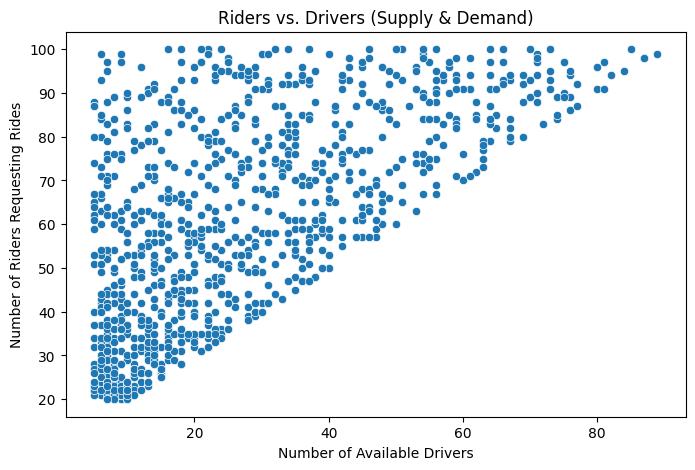

In [5]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['Number_of_Drivers'], y=df['Number_of_Riders'])
plt.title("Riders vs. Drivers (Supply & Demand)")
plt.xlabel("Number of Available Drivers")
plt.ylabel("Number of Riders Requesting Rides")
plt.show()


In [8]:
df["Demand_Supply_Ratio"] = df["Number_of_Riders"] / (df["Number_of_Drivers"] + 1)


In [9]:
# Define categorical and numerical features
categorical_features = ['Location_Category', 'Customer_Loyalty_Status', 'Time_of_Booking', 'Vehicle_Type']
numerical_features = ['Number_of_Riders', 'Number_of_Drivers', 'Number_of_Past_Rides',
                      'Average_Ratings', 'Expected_Ride_Duration', 'Demand_Supply_Ratio']

# Create a preprocessing pipeline
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_features),
    ('cat', OneHotEncoder(), categorical_features)
])


In [10]:
# Define features (X) and target variable (y)
X = df[numerical_features + categorical_features]
y = df['Historical_Cost_of_Ride']

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [11]:
# Create a machine learning pipeline
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Train the model
model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Number_of_Riders',
                                                   'Number_of_Drivers',
                                                   'Number_of_Past_Rides',
                                                   'Average_Ratings',
                                                   'Expected_Ride_Duration',
                                                   'Demand_Supply_Ratio']),
                                                 ('cat', OneHotEncoder(),
                                                  ['Location_Category',
                                                   'Customer_Loyalty_Status',
                                                   'Time_of_Booking',
                                                   'Vehicle_Type'])])),
                ('regressor', LinearRegression())])

In [12]:
# Predict ride prices on the test set
y_pred = model.predict(X_test)

# Calculate performance metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print evaluation metrics
print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"R-squared Score: {r2}")


Mean Absolute Error: 52.62429206282032
Mean Squared Error: 4569.57835436108
R-squared Score: 0.8746714831337985


In [13]:
def dynamic_pricing(row):
    """
    Adjusts ride pricing dynamically:
    - If Demand-Supply Ratio > 2, increase price by 15%.
    - If Demand-Supply Ratio < 0.5, decrease price by 10%.
    - Else, keep price unchanged.
    """
    if row['Demand_Supply_Ratio'] > 2:
        return row['Historical_Cost_of_Ride'] * 1.15  # Increase price by 15%
    elif row['Demand_Supply_Ratio'] < 0.5:
        return row['Historical_Cost_of_Ride'] * 0.9  # Decrease price by 10%
    else:
        return row['Historical_Cost_of_Ride']

# Apply dynamic pricing
df['New_Price'] = df.apply(dynamic_pricing, axis=1)

# Display first few rows of new prices
df[['Historical_Cost_of_Ride', 'New_Price']].head(10)


,Historical_Cost_of_Ride,New_Price
0,284.257273,284.257273
1,173.874753,173.874753
2,329.795469,329.795469
3,470.201232,540.731417
4,579.681422,666.633636
5,339.955361,339.955361
6,104.061541,119.670772
7,235.811864,235.811864
8,501.412517,576.624395
9,398.993365,458.842369


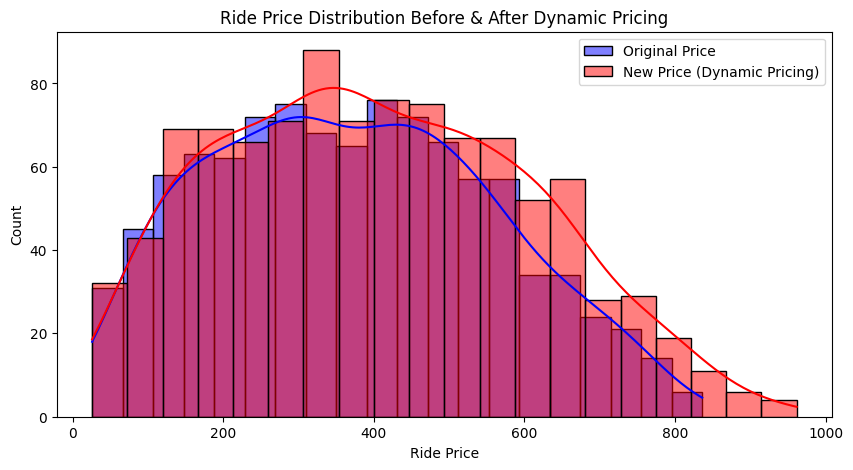

In [14]:
plt.figure(figsize=(10,5))
sns.histplot(df['Historical_Cost_of_Ride'], color="blue", label="Original Price", kde=True, bins=20)
sns.histplot(df['New_Price'], color="red", label="New Price (Dynamic Pricing)", kde=True, bins=20)
plt.title("Ride Price Distribution Before & After Dynamic Pricing")
plt.xlabel("Ride Price")
plt.legend()
plt.show()
